# Q3: Early Behavioural Signals and Later Intent / Switching Outcomes

Do the actions a customer takes in the months after first contact predict whether they'll show intent to switch or actually switch their mortgage?

**Sections:**
1. [Setup](#1-setup)
2. [Descriptive Analysis (EDA)](#2-descriptive-analysis)
3. [Data Quality](#3-data-quality)
4. [Analytical Unit â€” Mortgage-Level Base Table](#4-analytical-unit)
5. [Funnel Analysis](#5-funnel-analysis)
6. [Signal Strength](#6-signal-strength)
7. [Engagement Timing](#7-engagement-timing)
8. [Limitations and Further Evidence](#8-limitations)

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
# funnel stage order 
FUNNEL_STAGES = [
    'email_sent',
    'email_clicked',
    'logged_in',
    'subtopic_read',
    'start_review',
    'intent'
]

FUNNEL_LABELS = {
    'email_sent'    : 'Email sent',
    'email_clicked' : 'Clicked email',
    'logged_in'     : 'Logged in',
    'subtopic_read' : 'Read content',
    'start_review'  : 'Started review',
    'intent'        : 'Showed intent'
}

STATE_COLORS = {
    'open'     : '#5B8DB8',
    'switched' : '#E07B54',
    'redeemed' : '#68A96A'
}

# EDA

---
## 2. Descriptive Analysis

In [3]:
mortgages  = pd.read_csv('../seeds/mortgages.csv')
applicants = pd.read_csv('../seeds/applicants.csv')
events     = pd.read_csv('../seeds/events.csv')

# formatting dates
mortgages['mortgage_expiry_date'] = pd.to_datetime(mortgages['mortgage_expiry_date'])
mortgages['mortgage_closed_date'] = pd.to_datetime(mortgages['mortgage_closed_date'])
events['event_created_date']      = pd.to_datetime(events['event_created_date'])
# raw data has both 'email-sent' and 'email_sent' formats â€” normalise at load time
events['event_alias']             = events['event_alias'].str.replace('-', '_', regex=False)

print(f'mortgages : {mortgages.shape}')
print(f'applicants: {applicants.shape}')
print(f'events    : {events.shape}')

mortgages : (5000, 6)
applicants: (6660, 3)
events    : (57772, 5)


### 2.1 Mortgage portfolio

In [4]:
print(mortgages.info())
display(mortgages.head())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   firm_alias            5000 non-null   str           
 1   mortgage_id           5000 non-null   str           
 2   mortgage_expiry_date  5000 non-null   datetime64[us]
 3   mortgage_type         5000 non-null   str           
 4   mortgage_state        5000 non-null   str           
 5   mortgage_closed_date  1135 non-null   datetime64[us]
dtypes: datetime64[us](2), str(4)
memory usage: 234.5 KB
None


,firm_alias,mortgage_id,mortgage_expiry_date,mortgage_type,mortgage_state,mortgage_closed_date
0,Elderless,000c14c1-96e3-4cf6-9274-e85f756064be,2027-11-30,owner-occupied,open,NaT
1,Elderless,000f653c-51a9-4014-9486-53fe095b37b8,2029-09-30,owner-occupied,open,NaT
2,Elderless,001155c5-1664-43bc-b8a7-22277842830e,2026-09-28,buy-to-let,open,NaT
3,Roast Ham,0014c286-ba00-4574-ab52-af116f2a6c78,2028-03-31,owner-occupied,open,NaT
4,Elderless,001d4bd7-7e92-48b3-aa9a-f6a944bcfab4,2026-05-31,buy-to-let,switched,2026-03-05


In [5]:
mortgages.isnull().sum()

firm_alias                 0
mortgage_id                0
mortgage_expiry_date       0
mortgage_type              0
mortgage_state             0
mortgage_closed_date    3865
dtype: int64

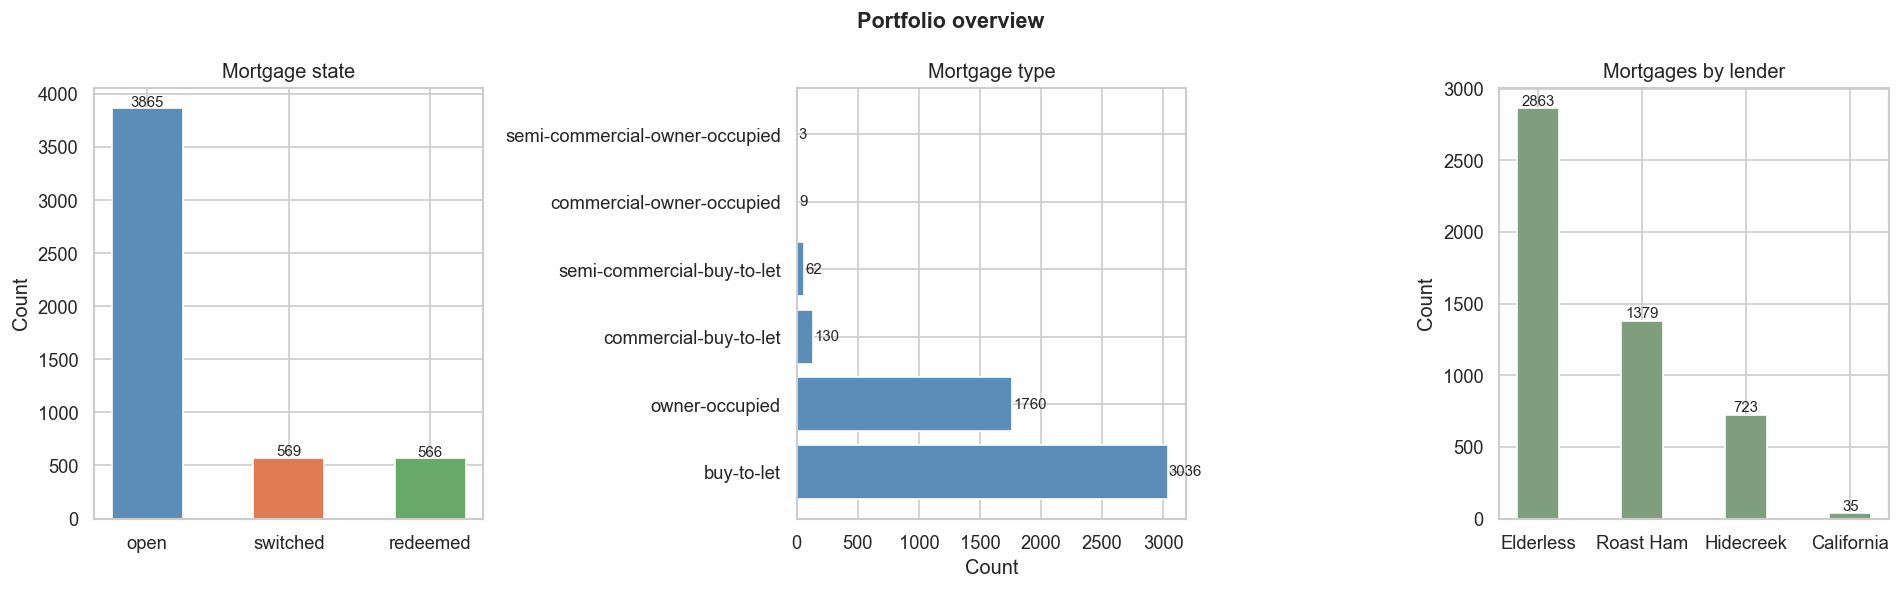

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# mortgage state
state_counts = mortgages['mortgage_state'].value_counts()
axes[0].bar(state_counts.index, state_counts.values,
            color=[STATE_COLORS.get(s, '#999') for s in state_counts.index],
            width=0.5)
axes[0].set_title('Mortgage state')
axes[0].set_ylabel('Count')
for i, v in enumerate(state_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# mortgage type
type_counts = mortgages['mortgage_type'].value_counts()
axes[1].barh(type_counts.index, type_counts.values, color='#5B8DB8')
axes[1].set_title('Mortgage type')
axes[1].set_xlabel('Count')
for i, v in enumerate(type_counts.values):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=9)

# lender
lender_counts = mortgages['firm_alias'].value_counts()
axes[2].bar(lender_counts.index, lender_counts.values, color='#7E9E7E', width=0.4)
axes[2].set_title('Mortgages by lender')
axes[2].set_ylabel('Count')
for i, v in enumerate(lender_counts.values):
    axes[2].text(i, v + 20, str(v), ha='center', fontsize=9)

plt.suptitle('Portfolio overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Elderless is the dominant lender in this dataset by a wide margin. Before drawing any cross-lender conclusions, it's worth asking why — the imbalance itself may be informative.

A few possible explanations:

1. Data completeness: the Roast Ham and California records may be incomplete. If only a subset of those lenders' portfolios was shared, any comparison of engagement or outcome rates could be misleading.
2. Commercial relationship: Eligible may have a longer or more established partnership with Elderless — meaning more of the engagement infrastructure (email cadences, funnel setup) is more mature for that lender than the others.
3. Geographic concentration: if Elderless operates primarily in high-density urban markets and the other lenders are newer or regionally concentrated elsewhere, the signals will partly reflect market conditions rather than lender differences. California's sample is four mortgages in the full cohort — too small to draw any conclusions from.

Without more context on how the data was collected, I'll treat cross-lender comparison

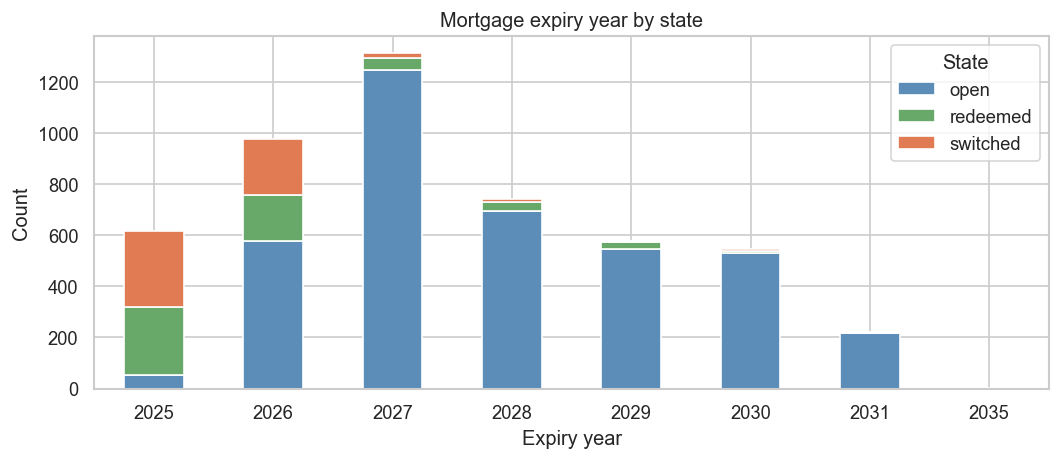

In [7]:
# expiry date distribution â€” shows when the portfolio comes up for renewal
mortgages['expiry_year'] = mortgages['mortgage_expiry_date'].dt.year
expiry_dist = mortgages.groupby(['expiry_year', 'mortgage_state']).size().unstack(fill_value=0)

expiry_dist.plot(kind='bar', stacked=True,
                 color=[STATE_COLORS.get(c, '#999') for c in expiry_dist.columns],
                 figsize=(9, 4))
plt.title('Mortgage expiry year by state')
plt.xlabel('Expiry year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='State')
plt.tight_layout()
plt.show()

Most mortgages that expired in 2025 still show as 'open' — by mid-2026, those customers would have had to either switch, redeem, or roll onto their lender's standard variable rate. This points to two meaningfully different situations within the 'open' label:

1. Within fixed term: the mortgage hasn't reached its expiry date yet. No action is needed and 'open' is the correct status.
2. Post-expiry with no action recorded: the fixed term ended but no outcome was captured. Either the customer rolled onto the SVR (which isn't tracked as a state change), the outcome data is missing from the extract, or there's a gap in the data pipeline that hasn't been addressed.

Both groups behave differently and shouldn't be treated as equivalent non-movers.

### 2.2 Event volume and timeline

In [8]:
print(events.info())
display(events.head())

<class 'pandas.DataFrame'>
RangeIndex: 57772 entries, 0 to 57771
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_id            57772 non-null  str           
 1   event_consumer_id   57772 non-null  str           
 2   event_mortgage_id   19664 non-null  str           
 3   event_created_date  57772 non-null  datetime64[us]
 4   event_alias         57772 non-null  str           
dtypes: datetime64[us](1), str(4)
memory usage: 2.2 MB
None


,event_id,event_consumer_id,event_mortgage_id,event_created_date,event_alias
0,f173efb7-460d-4533-8619-9d6ad8368e5b,a5f48d8b-aeec-4f60-9d03-bb94efe67f23,fc116973-d81a-4cec-a831-e037e36d48af,2024-05-01,email_sent
1,6eddedd8-23fe-442c-bede-9c00911370f8,ea82170e-0e1f-4a64-9b49-09ef86874ac0,b0a17481-a9f8-4833-9948-77c2cb90ea3c,2024-05-01,email_sent
2,a7cbc847-3afd-439a-99c7-f0b55a443d3a,0cd8a47a-670f-4169-bcd4-b0e1c6cf4bb5,5b0409a6-fe08-4a12-8b71-cd83d0c54789,2024-05-01,email_sent
3,9bc71cd8-43b5-41fb-b268-d4a44bd5cc08,d1a23691-6dbb-41c8-baf7-beda3af5a257,9c69553f-bbd4-4e21-8693-6d982f0e627b,2024-05-01,email_sent
4,80ca049b-d21d-4e1d-9fa8-88a2119a9cd9,86a3c0a8-5957-48af-8b09-3f1611b3f899,46e7d0e1-838e-4aa1-b85c-a5d93b350469,2024-05-01,email_sent


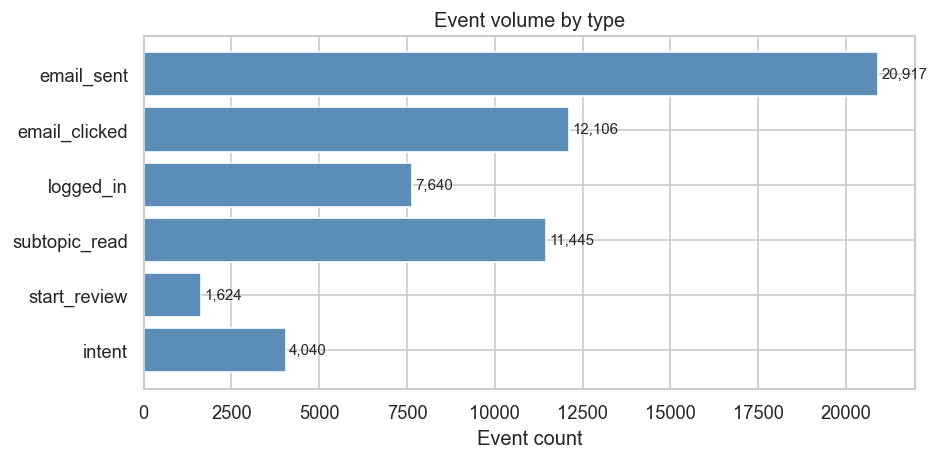

In [9]:
# event type volume
event_counts = events['event_alias'].value_counts().reindex(
    [e for e in FUNNEL_STAGES if e in events['event_alias'].unique()] +
    [e for e in events['event_alias'].unique() if e not in FUNNEL_STAGES]
).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(event_counts.index[::-1], event_counts.values[::-1], color='#5B8DB8')
ax.set_xlabel('Event count')
ax.set_title('Event volume by type')
for i, v in enumerate(event_counts.values[::-1]):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

logged_in < subtopic_read: at first this seemed off, but it makes sense if sessions stay open between visits — a content read can happen without triggering a new login event. The two aren't directly comparable.

intent > start_review: more interesting. There are more intent signals than review starts, which means a lot of customers are showing intent without having gone through the review flow — likely clicking a direct link or email rather than navigating through the full funnel. If that's the case, start_review understates how many people are actually engaged, and the funnel isn't as sequential as it looks.

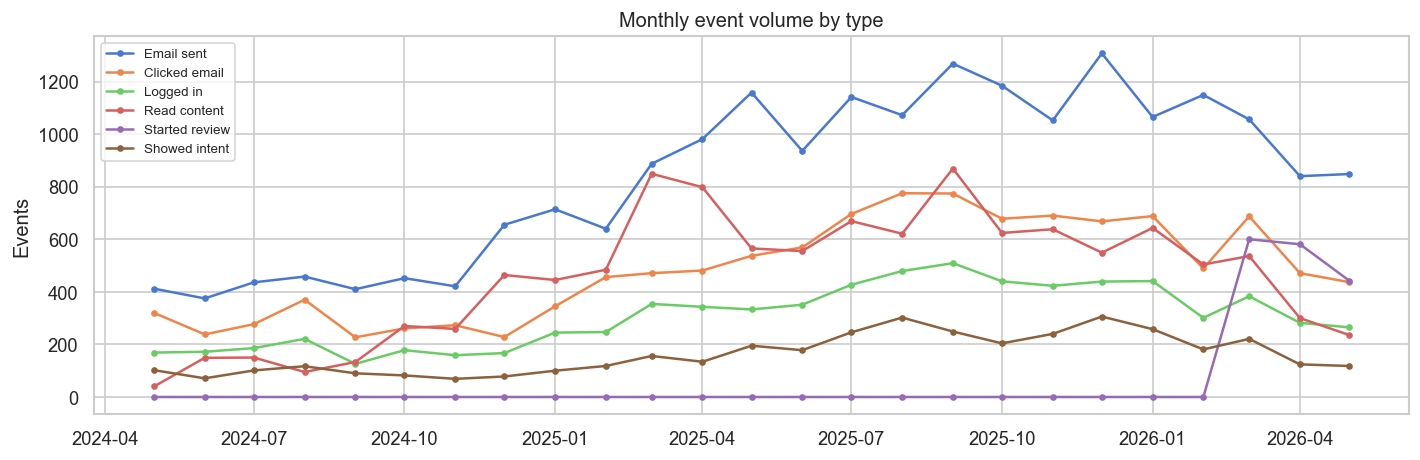

In [10]:
# monthly event volume per type â€” shows when engagement started and any trends
events['event_month'] = events['event_created_date'].dt.to_period('M')
monthly = events.groupby(['event_month', 'event_alias']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
for col in FUNNEL_STAGES:
    if col in monthly.columns:
        ax.plot(monthly.index, monthly[col], marker='o', markersize=3, label=FUNNEL_LABELS[col])
ax.set_title('Monthly event volume by type')
ax.set_xlabel('')
ax.set_ylabel('Events')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Email volume grew roughly 3x between mid-2024 and late 2025, but intent events stayed flat — the funnel leaks heavily between click and stated intent for most customers.

start_review is effectively a new event: it's near-zero until early 2026, which is why it doesn't fit the rest of the funnel chronologically. Worth understanding what was the rational or the reason for the company to introduce this new event, the benefits for the product and the special considerations in terms of data

### 2.3 Applicants bridge many-to-many sizing

In [11]:
print(applicants.dtypes)
display(applicants.head())

mortgages_per_consumer = applicants.groupby('applicant_consumer_id')['applicant_mortgage_id'].nunique()
consumers_per_mortgage = applicants.groupby('applicant_mortgage_id')['applicant_consumer_id'].nunique()

print('\nMortgages per consumer:')
print(mortgages_per_consumer.value_counts().sort_index().rename('consumers'))

print('\nConsumers per mortgage:')
print(consumers_per_mortgage.value_counts().sort_index().rename('mortgages'))

applicant_id             str
applicant_consumer_id    str
applicant_mortgage_id    str
dtype: object


,applicant_id,applicant_consumer_id,applicant_mortgage_id
0,003c2ee1-b1d7-4295-9169-1c8455a2d9be,d61a6341-6305-4294-bfa0-44623635b72d,0ad9e09f-b092-42b0-a831-070c84ff32f8
1,015743b7-6563-413d-ab5a-1fc7218c5f1a,8996a93b-17e8-4e41-8841-24dc63290847,07062ea1-039c-4526-af79-7879a62e9bab
2,0268a97e-8919-4fd2-b2cc-f229c3c44a37,55ba4817-d9b0-4f3a-b6e8-073be93ba546,07512a4c-8123-4d51-ba10-a7b8c793e3a5
3,039b8558-9e78-415d-80f7-edc2e0635d2a,92c6f86f-b9c4-47b0-9584-a74e72fc36e5,083ee71e-e42e-466f-a3fc-48890dd946fb
4,03b04bd2-26f3-4c02-b860-191c1fe99981,07bac8a7-60be-4302-bf6e-3c4df1b7e392,01891661-357e-4160-a07b-c0dcebaceb27



Mortgages per consumer:
applicant_mortgage_id
1    6282
2     165
3      13
4       1
5       1
Name: consumers, dtype: int64

Consumers per mortgage:
applicant_consumer_id
1     1922
2     2310
3       12
4       11
5        1
33       1
Name: mortgages, dtype: int64


### 2.4 Missing values profile

In [12]:
def null_profile(df, label):
    pct = (df.isnull().sum() / len(df) * 100).rename('null_%')
    counts = df.isnull().sum().rename('null_count')
    return pd.concat([counts, pct], axis=1).assign(table=label)

null_summary = pd.concat([
    null_profile(mortgages, 'mortgages'),
    null_profile(applicants, 'applicants'),
    null_profile(events, 'events')
])

display(null_summary[null_summary['null_count'] > 0].sort_values('null_%', ascending=False))

,null_count,null_%,table
mortgage_closed_date,3865,77.30,mortgages
event_mortgage_id,38108,65.96,events


mortgage_closed_date being 77% null is expected — most mortgages are still open or switched without a formal close date recorded.

event_mortgage_id being 66% null is the bigger issue: the majority of events carry no mortgage reference, so most engagement activity can only be attributed to a mortgage indirectly via the consumer → applicants bridge. This limits what can be reliably measured at mortgage level.

In [13]:
# null event_mortgage_id broken down by event type -- intent is expected to be near 100% null
null_by_type = (
    events
    .assign(mortgage_id_null=events['event_mortgage_id'].isna())
    .groupby('event_alias')['mortgage_id_null']
    .agg(['sum', 'count'])
    .assign(pct_null=lambda df: df['sum'] / df['count'] * 100)
    .rename(columns={'sum': 'null_count', 'count': 'total'})
    .sort_values('pct_null', ascending=False)
)
display(null_by_type)


,null_count,total,pct_null
event_alias,,,
email_clicked,12106,12106,100.00
intent,4040,4040,100.00
start_review,1624,1624,100.00
logged_in,7640,7640,100.00
subtopic_read,11445,11445,100.00
email_sent,1253,20917,5.99


---
## 3. Data Quality

In [14]:
# any open mortgages that already have a closed_date?
dq_open_with_close = mortgages[
    (mortgages['mortgage_state'] == 'open') & mortgages['mortgage_closed_date'].notna()
]
print(f'Open mortgages with a closed_date: {len(dq_open_with_close)} '
      f'({len(dq_open_with_close)/len(mortgages)*100:.1f}%)')
display(dq_open_with_close.head())

Open mortgages with a closed_date: 0 (0.0%)


,firm_alias,mortgage_id,mortgage_expiry_date,mortgage_type,mortgage_state,mortgage_closed_date,expiry_year


In [15]:
# engagement events don't carry a mortgage_id â€” they're consumer-level
# routing to a mortgage goes via the applicants table
engagement_types = ['email_clicked', 'logged_in', 'subtopic_read', 'start_review', 'intent']
dq_no_mortgage = events[
    events['event_alias'].isin(engagement_types) & events['event_mortgage_id'].isna()
]
print(f'Engagement events with no mortgage_id: {len(dq_no_mortgage):,} '
      f'({len(dq_no_mortgage)/len(events)*100:.1f}% of all events)')
print('Note: intent events are consumer-level by design, so nulls here are expected.')
display(dq_no_mortgage['event_alias'].value_counts())

Engagement events with no mortgage_id: 36,855 (63.8% of all events)
Note: intent events are consumer-level by design, so nulls here are expected.


event_alias
email_clicked    12106
subtopic_read    11445
logged_in         7640
intent            4040
start_review      1624
Name: count, dtype: int64

In [16]:
# mortgages with no consumer record â€” can't be attributed any signals
mortgages_no_consumer = mortgages[
    ~mortgages['mortgage_id'].isin(applicants['applicant_mortgage_id'])
]
print(f'Mortgages with no consumer in applicants: {len(mortgages_no_consumer)} '
      f'({len(mortgages_no_consumer)/len(mortgages)*100:.1f}%)')

Mortgages with no consumer in applicants: 1750 (35.0%)


In [17]:
# closed before expiry? expected for mid-term switches and redemptions
closed_before_expiry = mortgages[
    mortgages['mortgage_closed_date'].notna() &
    (mortgages['mortgage_closed_date'] < mortgages['mortgage_expiry_date'])
]
print(f'Mortgages closed before expiry: {len(closed_before_expiry)} '
      f'â€” these are expected (switching/redemption happens mid-term)')

Mortgages closed before expiry: 755 â€” these are expected (switching/redemption happens mid-term)


In [18]:
# event_alias uses two formats for the same types in the raw data (hyphen vs underscore)
# documenting the raw state here â€” the fix is applied at load time above
raw_events = pd.read_csv('../seeds/events.csv')
alias_counts = raw_events['event_alias'].value_counts()
hyphenated = alias_counts[alias_counts.index.str.contains('-')]
print('Event types with hyphenated aliases in raw data:')
print(hyphenated.to_frame('count').to_string())
print(f'\nTotal affected: {hyphenated.sum():,} events')
print('Fix: normalised to underscore format at load time')

Event types with hyphenated aliases in raw data:
               count
event_alias         
email-sent     14076
email-clicked   8159
subtopic-read   7309
logged-in       5073
start-review    1624

Total affected: 36,241 events
Fix: normalised to underscore format at load time


---
## 4. Analytical Unit

One row per mortgage. All joins are **left joins** starting from `mortgages` so nothing is silently dropped. Nulls are preserved and categorised.

**Why left join instead of inner join?**  
An inner join (only mortgages that appear in applicants *and* have events) conditions the analysis on having been engaged. That inflates engagement rates because the denominator excludes mortgages that were never reached. Left joining and flagging nulls keeps the denominator honest.

In [19]:
# one consumer per mortgage  use first applicant record if a mortgage has multiple
primary_consumer = (
    applicants
    .groupby('applicant_mortgage_id')['applicant_consumer_id']
    .first()
    .reset_index()
    .rename(columns={
        'applicant_mortgage_id': 'mortgage_id',
        'applicant_consumer_id': 'consumer_id'
    })
)

base = (
    mortgages
    .rename(columns={
        'mortgage_id'           : 'mortgage_id',
        'firm_alias'            : 'lender',
        'mortgage_type'         : 'mortgage_type',
        'mortgage_state'        : 'mortgage_state',
        'mortgage_expiry_date'  : 'expiry_date',
        'mortgage_closed_date'  : 'closed_date'
    })
    .merge(primary_consumer, on='mortgage_id', how='left')
)

print(f'Base after consumer join: {len(base)} rows')

Base after consumer join: 5000 rows


35% of mortgages (1,750) have no record in the applicants table, so their `consumer_id` is null throughout. These mortgages cannot be attributed any engagement signal -- not because the data is missing, but because the applicants bridge is how the platform links consumers to mortgages. No bridge record means no way to route events to that mortgage.

The dbt models (`int_mortgage_cohorts`, `int_engagement_spine`) use the same approach: left join from the mortgages table so that all mortgages stay in scope, with nulls preserved for the ones that were never reachable through the consumer system. This keeps the denominator honest -- switching and intent rates are calculated against all mortgages, not just the ones the platform could track.

In [20]:
# first email per mortgage (email_sent events carry a mortgage_id directly)
first_email = (
    events[events['event_alias'] == 'email_sent']
    .groupby('event_mortgage_id')['event_created_date']
    .min()
    .reset_index()
    .rename(columns={
        'event_mortgage_id'  : 'mortgage_id',
        'event_created_date' : 'first_email_date'
    })
)

base = base.merge(first_email, on='mortgage_id', how='left')

In [21]:
# intent events do not carry a mortgage_id â€” resolve via consumer bridge
# if a consumer holds multiple mortgages, intent is attributed to all of them
intent_via_consumer = (
    events[events['event_alias'] == 'intent']
    .merge(
        applicants.rename(columns={
            'applicant_consumer_id': 'event_consumer_id',
            'applicant_mortgage_id': 'mortgage_id'
        }),
        on='event_consumer_id',
        how='inner'
    )
    .groupby('mortgage_id')['event_created_date']
    .min()
    .reset_index()
    .rename(columns={'event_created_date': 'first_intent_date'})
)

base = base.merge(intent_via_consumer, on='mortgage_id', how='left')

# how many mortgages were touched by the multi-mortgage consumer attribution?
multi_mortgage_consumers = applicants.groupby('applicant_consumer_id')['applicant_mortgage_id'].nunique()
n_multi = (multi_mortgage_consumers > 1).sum()
print(f'Consumers with >1 mortgage: {n_multi} intent events for these consumers '
      f'are attributed to all their mortgages')

Consumers with >1 mortgage: 180 intent events for these consumers are attributed to all their mortgages


In [22]:
# all engagement events route via consumer bridge (no mortgage_id on these events)
# filter to months 1-3 after first email -- matches int_engagement_funnel dbt model
direct_events = ['email_clicked', 'logged_in', 'subtopic_read', 'start_review', 'intent']

for alias in direct_events:
    reached = (
        events[events['event_alias'] == alias]
        .merge(
            applicants.rename(columns={
                'applicant_consumer_id': 'event_consumer_id',
                'applicant_mortgage_id': 'mortgage_id'
            }),
            on='event_consumer_id',
            how='inner'
        )
        .merge(
            base[['mortgage_id', 'first_email_date']].dropna(subset=['first_email_date']),
            on='mortgage_id',
            how='inner'
        )
        .assign(
            months_since_start=lambda df: (
                (df['event_created_date'].dt.year * 12 + df['event_created_date'].dt.month) -
                (df['first_email_date'].dt.year * 12 + df['first_email_date'].dt.month)
            ) + 1
        )
        .query('1 <= months_since_start <= 3')
        .groupby('mortgage_id').size()
        .reset_index(name='_cnt')
        .assign(**{f'reached_{alias}': 1})
        [['mortgage_id', f'reached_{alias}']]
    )
    base = base.merge(reached, on='mortgage_id', how='left')
    base[f'reached_{alias}'] = base[f'reached_{alias}'].fillna(0).astype(int)

# derived binary flags
base['had_intent']  = base['first_intent_date'].notna().astype(int)  # any time, used in signal analysis
base['is_switched'] = (base['mortgage_state'] == 'switched').astype(int)
base['in_cohort']   = base['first_email_date'].notna().astype(int)
base['reached_email_sent'] = base['in_cohort']

# funnel stage: highest stage reached (ordinal 0-6), matching int_engagement_funnel
FUNNEL_STAGE_COLS = [
    'reached_email_sent', 'reached_email_clicked', 'reached_logged_in',
    'reached_subtopic_read', 'reached_start_review', 'reached_intent'
]
FUNNEL_STAGE_LABELS_MAP = {
    0: 'No engagement', 1: 'Email sent',    2: 'Clicked email',
    3: 'Logged in',     4: 'Read content', 5: 'Started review', 6: 'Showed intent'
}

def _highest_stage(row):
    for i, col in enumerate(reversed(FUNNEL_STAGE_COLS), 1):
        if row[col] == 1:
            return len(FUNNEL_STAGE_COLS) + 1 - i
    return 0

base['funnel_stage_reached'] = base[FUNNEL_STAGE_COLS].apply(_highest_stage, axis=1)
base['funnel_stage_label']   = base['funnel_stage_reached'].map(FUNNEL_STAGE_LABELS_MAP)
base['funnel_stage'] = base['funnel_stage_reached']  # kept for chart compatibility

FUNNEL_FLAG_COLS = ['reached_email_clicked', 'reached_logged_in',
                    'reached_subtopic_read', 'reached_start_review', 'reached_intent']

base['days_to_intent'] = (base['first_intent_date'] - base['first_email_date']).dt.days
base['days_to_close']  = (base['closed_date'] - base['first_email_date']).dt.days

print(f'Base table shape: {base.shape}')
print('Funnel flag totals (months 1-3):')
print(base[FUNNEL_FLAG_COLS].sum())


Base table shape: (5000, 24)
Funnel flag totals (months 1-3):
reached_email_clicked    434
reached_logged_in        411
reached_subtopic_read    248
reached_start_review      85
reached_intent           151
dtype: int64


In [23]:
# analytical universe waterfall shows exactly how many mortgages are in scope at each stage
waterfall = pd.DataFrame([
    {'Universe'                                : 'All mortgages',
     'Count'                                   : len(base)},
    {'Universe'                                : 'Has a consumer (in applicants)',
     'Count'                                   : base['consumer_id'].notna().sum()},
    {'Universe'                                : 'Has at least one event (via consumer)',
     'Count'                                   : base[
         base['consumer_id'].isin(events['event_consumer_id'])
     ]['mortgage_id'].nunique()},
    {'Universe'                                : 'Has first email_sent (cohort)',
     'Count'                                   : base['in_cohort'].sum()},
    {'Universe'                                : 'Showed intent',
     'Count'                                   : base['had_intent'].sum()},
    {'Universe'                                : 'Switched',
     'Count'                                   : base['is_switched'].sum()},
])
waterfall['% of total'] = (waterfall['Count'] / len(base) * 100).round(1)
display(waterfall)

,Universe,Count,% of total
0,All mortgages,5000,100.00
1,Has a consumer (in applicants),3250,65.00
2,Has at least one event (via consumer),1329,26.60
3,Has first email_sent (cohort),860,17.20
4,Showed intent,625,12.50
5,Switched,569,11.40


---
## 5. Funnel Analysis

The cohort is mortgages with a `first_email_date` i.e. the lender sent at least one email. All funnel rates use this cohort as the denominator.

In [24]:
cohort = base[base['in_cohort'] == 1].copy()
print(f'Cohort size (mortgages with email_sent): {len(cohort)}')

Cohort size (mortgages with email_sent): 860


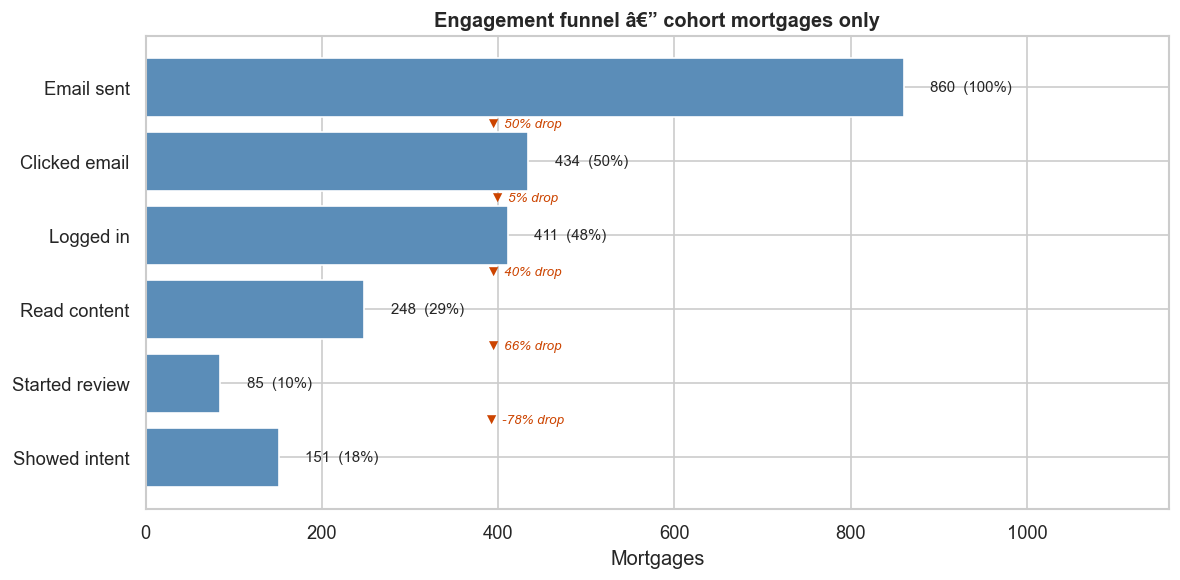

In [25]:
# Chart 1: Funnel volume + stage-to-stage conversion rates

flag_cols = [
    'reached_email_sent',
    'reached_email_clicked',
    'reached_logged_in',
    'reached_subtopic_read',
    'reached_start_review',
    'reached_intent'
]

funnel_counts = {s: cohort[f].sum() for s, f in zip(FUNNEL_STAGES, flag_cols)}
funnel_df = pd.DataFrame(list(funnel_counts.items()), columns=['stage', 'count'])
funnel_df['label'] = funnel_df['stage'].map(FUNNEL_LABELS)
funnel_df['pct_of_total'] = funnel_df['count'] / len(cohort) * 100
funnel_df['stage_to_stage'] = funnel_df['count'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    funnel_df['label'][::-1],
    funnel_df['count'][::-1],
    color='#5B8DB8'
)

for i, (_, row) in enumerate(funnel_df[::-1].iterrows()):
    ax.text(row['count'] + 30, i, f"{row['count']:,}  ({row['pct_of_total']:.0f}%)",
            va='center', fontsize=9)

# annotate drop-offs between stages
for i in range(1, len(funnel_df)):
    prev = funnel_df.iloc[i - 1]['count']
    curr = funnel_df.iloc[i]['count']
    drop = (1 - curr / prev) * 100 if prev > 0 else 0
    # position in reversed chart: stage i is at position len-1-i from the top
    y_pos = len(funnel_df) - 1 - i + 0.5
    ax.text(max(funnel_df['count']) * 0.5, y_pos,
            f'▼ {drop:.0f}% drop',
            va='center', ha='center', fontsize=8, color='#cc4400',
            style='italic')

ax.set_xlabel('Mortgages')
ax.set_title('Engagement funnel â€” cohort mortgages only', fontweight='bold')
ax.set_xlim(0, max(funnel_df['count']) * 1.35)
plt.tight_layout()
plt.show()

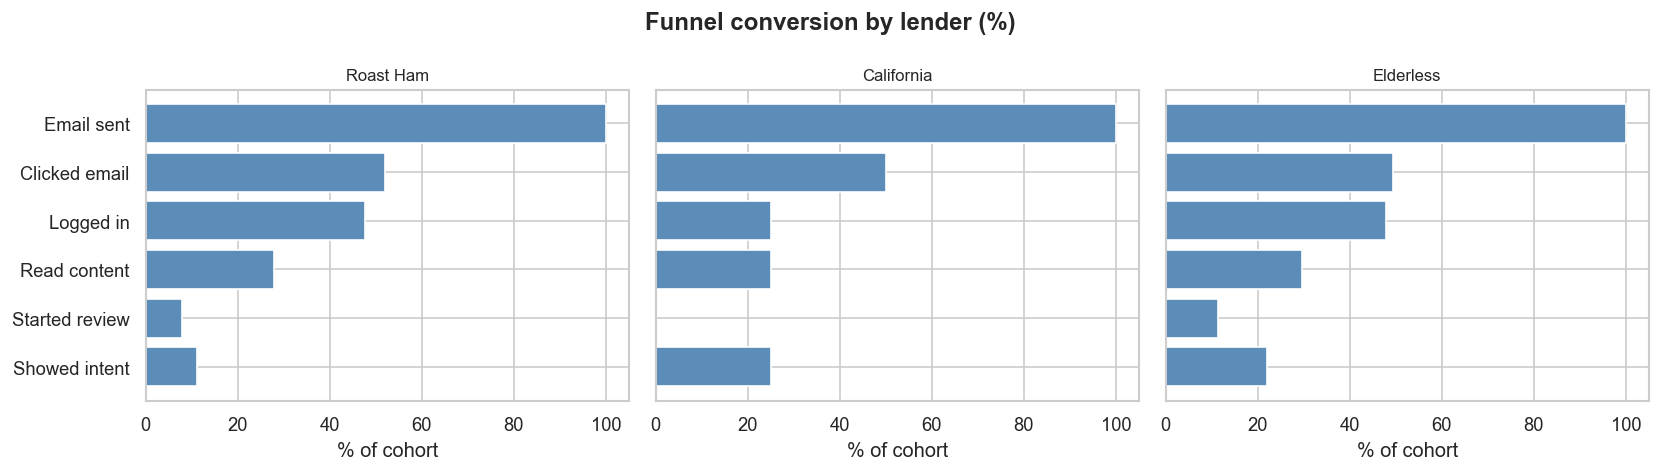

In [26]:
# Chart 2: Funnel by lender do all lenders have the same shape?
lenders = cohort['lender'].unique()
fig, axes = plt.subplots(1, len(lenders), figsize=(14, 4), sharey=True)

for ax, lender in zip(axes, lenders):
    sub = cohort[cohort['lender'] == lender]
    counts = [sub[f].sum() for f in flag_cols]
    pcts   = [c / len(sub) * 100 for c in counts]
    ax.barh([FUNNEL_LABELS[s] for s in FUNNEL_STAGES][::-1],
            pcts[::-1], color='#5B8DB8')
    ax.set_title(lender, fontsize=10)
    ax.set_xlabel('% of cohort')

fig.suptitle('Funnel conversion by lender (%)', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.0 Two types of open

Not all open mortgages are the same. A mortgage shows as 'open' both while it's still in its fixed term and after that term has ended â€” the difference matters when reading the signal charts below.

- **Post-expiry open**: the fixed term ended and the customer rolled onto the lender's standard variable rate. They had a decision point and didn't act â€” a genuine non-mover.
- **Pre-expiry open**: still within the fixed term. No decision has been needed yet, so calling them a non-mover is premature.

About half the open mortgages haven't reached their expiry date yet. Their outcome is still in the future, some will eventually switch or redeem as the portfolio matures.

In [27]:
today = pd.Timestamp('2026-06-12')

open_base = base[base['mortgage_state'] == 'open'].copy()
open_base['expiry_status'] = np.where(
    open_base['expiry_date'] <= today,
    'post-expiry (SVR rollover)',
    'pre-expiry (outcome pending)'
)

print('Open mortgages by expiry status:')
print(open_base['expiry_status'].value_counts().to_frame('count').to_string())

# add flags to base table for use in signal charts below
base['open_post_expiry'] = (
    (base['mortgage_state'] == 'open') & (base['expiry_date'] <= today)
).astype(int)
base['open_pre_expiry'] = (
    (base['mortgage_state'] == 'open') & (base['expiry_date'] > today)
).astype(int)

pct_pre = (open_base['expiry_status'] == 'pre-expiry (outcome pending)').mean() * 100
print(f'\n{pct_pre:.0f}% of open mortgages have not yet reached their expiry date')

Open mortgages by expiry status:
                              count
expiry_status                      
pre-expiry (outcome pending)   3708
post-expiry (SVR rollover)      157

96% of open mortgages have not yet reached their expiry date


In [28]:
# logistic regression: which signals independently predict switching?
# restricted to cohort mortgages -- cannot generate signals without an email first
from sklearn.linear_model import LogisticRegression

cohort_lr = base[base['in_cohort'] == 1].copy()

features = ['had_intent', 'reached_start_review', 'reached_subtopic_read',
            'reached_logged_in', 'reached_email_clicked']
X = cohort_lr[features].values
y = cohort_lr['is_switched'].values

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X, y)

or_table = pd.DataFrame({
    'feature'    : features,
    'coef'       : lr.coef_[0],
    'odds_ratio' : np.exp(lr.coef_[0])
}).sort_values('odds_ratio', ascending=False).round(3)

display(or_table)


,feature,coef,odds_ratio
0,had_intent,0.85,2.34
2,reached_subtopic_read,0.43,1.54
3,reached_logged_in,0.15,1.17
4,reached_email_clicked,0.05,1.05
1,reached_start_review,-1.02,0.36


`had_intent` has the largest coefficient by a wide margin. The earlier funnel stages all have positive associations with switching but add little independent predictive power once intent is in the model. This makes sense: a customer who eventually shows intent will almost always have passed through those earlier stages too, so the signals are correlated with each other.

The model explains only a small share of the variance in switching outcomes, which is expected -- the main driver of switching (the gap between the customer's current rate and available market rates) is not in this dataset.

---
## 6. Signal Strength

Does reaching deeper into the funnel actually predict switching?

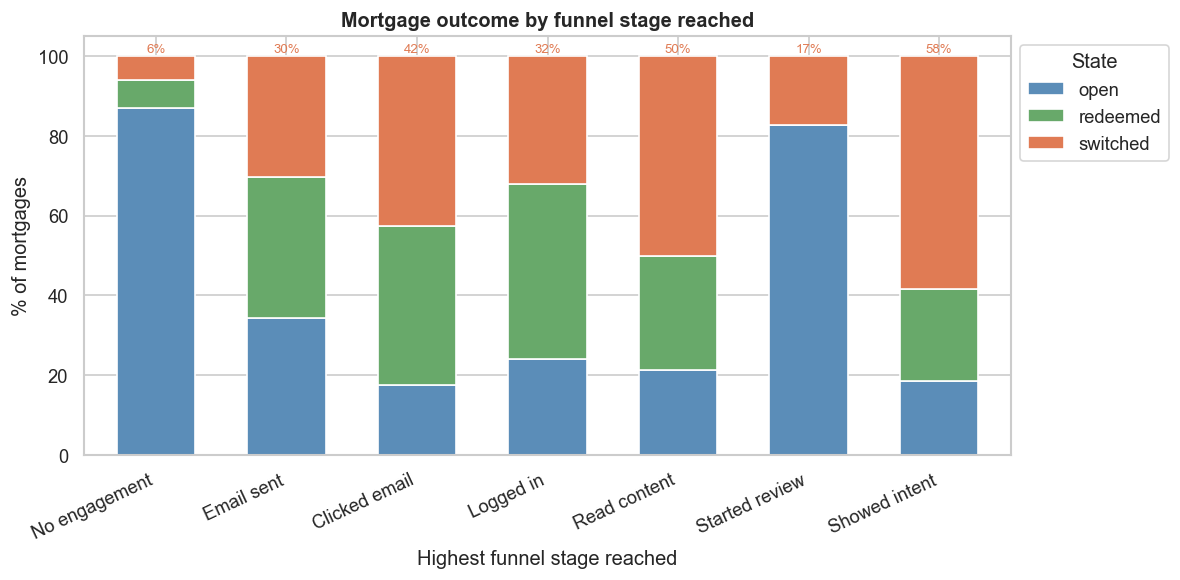

In [29]:
# Chart 3: outcome by funnel stage reached -- uses highest-stage label from base
# matches int_engagement_funnel dbt model stage ordering

STAGE_ORDER = [
    'No engagement', 'Email sent', 'Clicked email', 'Logged in',
    'Read content', 'Started review', 'Showed intent'
]

stage_outcome = (
    base
    .groupby(['funnel_stage_label', 'mortgage_state'])
    .size()
    .unstack(fill_value=0)
)
stage_pct = stage_outcome.div(stage_outcome.sum(axis=1), axis=0) * 100

stage_order = [s for s in STAGE_ORDER if s in stage_pct.index]
stage_pct = stage_pct.reindex(stage_order)

ax = stage_pct.plot(
    kind='bar', stacked=True,
    color=[STATE_COLORS.get(c, '#999') for c in stage_pct.columns],
    figsize=(10, 5),
    width=0.6
)
ax.set_xlabel('Highest funnel stage reached')
ax.set_ylabel('% of mortgages')
ax.set_title('Mortgage outcome by funnel stage reached', fontweight='bold')
ax.set_xticklabels(stage_order, rotation=25, ha='right')
ax.legend(title='State', bbox_to_anchor=(1, 1))

for i, stage in enumerate(stage_order):
    if 'switched' in stage_pct.columns:
        switch_pct = stage_pct.loc[stage, 'switched']
        ax.text(i, 101, f'{switch_pct:.0f}%', ha='center', fontsize=8, color='#E07B54')

plt.tight_layout()
plt.show()


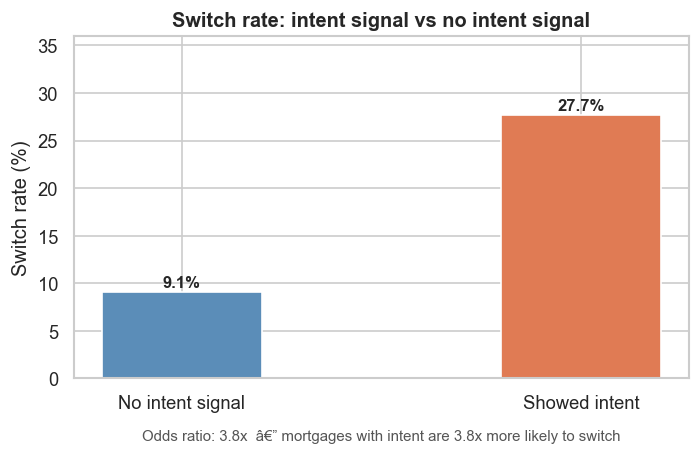

In [30]:
# Chart 4: Intent flag vs switch rate â€” the headline signal

intent_switch = (
    base
    .groupby('had_intent')['is_switched']
    .agg(['sum', 'count'])
    .assign(switch_rate=lambda df: df['sum'] / df['count'] * 100)
    .reset_index()
)
intent_switch['label'] = intent_switch['had_intent'].map({0: 'No intent signal', 1: 'Showed intent'})

# odds ratio
r_intent     = intent_switch.loc[intent_switch['had_intent'] == 1, 'switch_rate'].values[0] / 100
r_no_intent  = intent_switch.loc[intent_switch['had_intent'] == 0, 'switch_rate'].values[0] / 100
odds_ratio   = (r_intent / (1 - r_intent)) / (r_no_intent / (1 - r_no_intent))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    intent_switch['label'],
    intent_switch['switch_rate'],
    color=['#5B8DB8', '#E07B54'],
    width=0.4
)
for bar, rate in zip(bars, intent_switch['switch_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Switch rate (%)')
ax.set_title('Switch rate: intent signal vs no intent signal', fontweight='bold')
ax.set_ylim(0, max(intent_switch['switch_rate']) * 1.3)
ax.text(0.5, -0.18,
        f'Odds ratio: {odds_ratio:.1f}x  â€” '
        f'mortgages with intent are {odds_ratio:.1f}x more likely to switch',
        transform=ax.transAxes, ha='center', fontsize=9, color='#555')
plt.tight_layout()
plt.show()

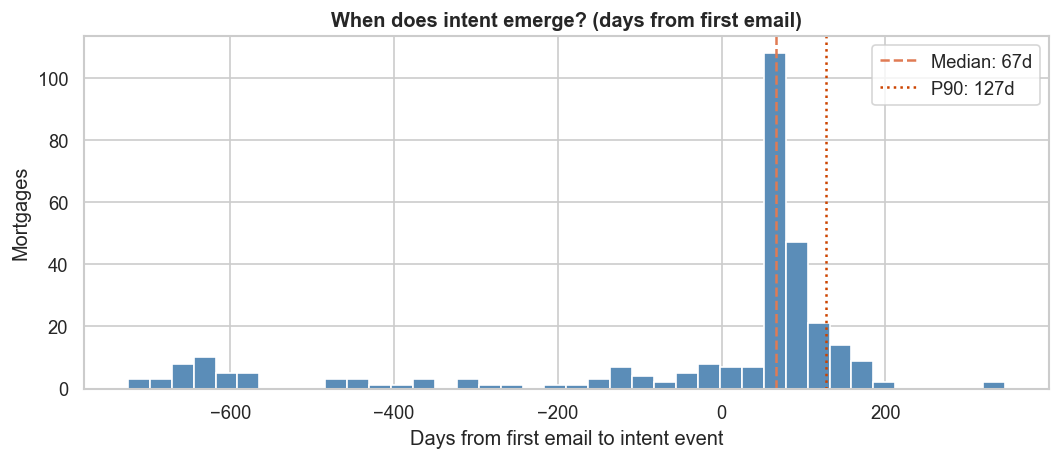

Median days to intent: 67
90% of intent occurs within 127 days


In [31]:
# Chart 5: Days-to-intent distribution

days_data = base[
    base['had_intent'] == 1
]['days_to_intent'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(days_data, bins=40, color='#5B8DB8', edgecolor='white')

med   = days_data.median()
p90   = days_data.quantile(0.90)
ax.axvline(med, color='#E07B54', linestyle='--', label=f'Median: {med:.0f}d')
ax.axvline(p90, color='#cc4400', linestyle=':',  label=f'P90: {p90:.0f}d')

ax.set_xlabel('Days from first email to intent event')
ax.set_ylabel('Mortgages')
ax.set_title('When does intent emerge? (days from first email)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median days to intent: {med:.0f}')
print(f'90% of intent occurs within {p90:.0f} days')

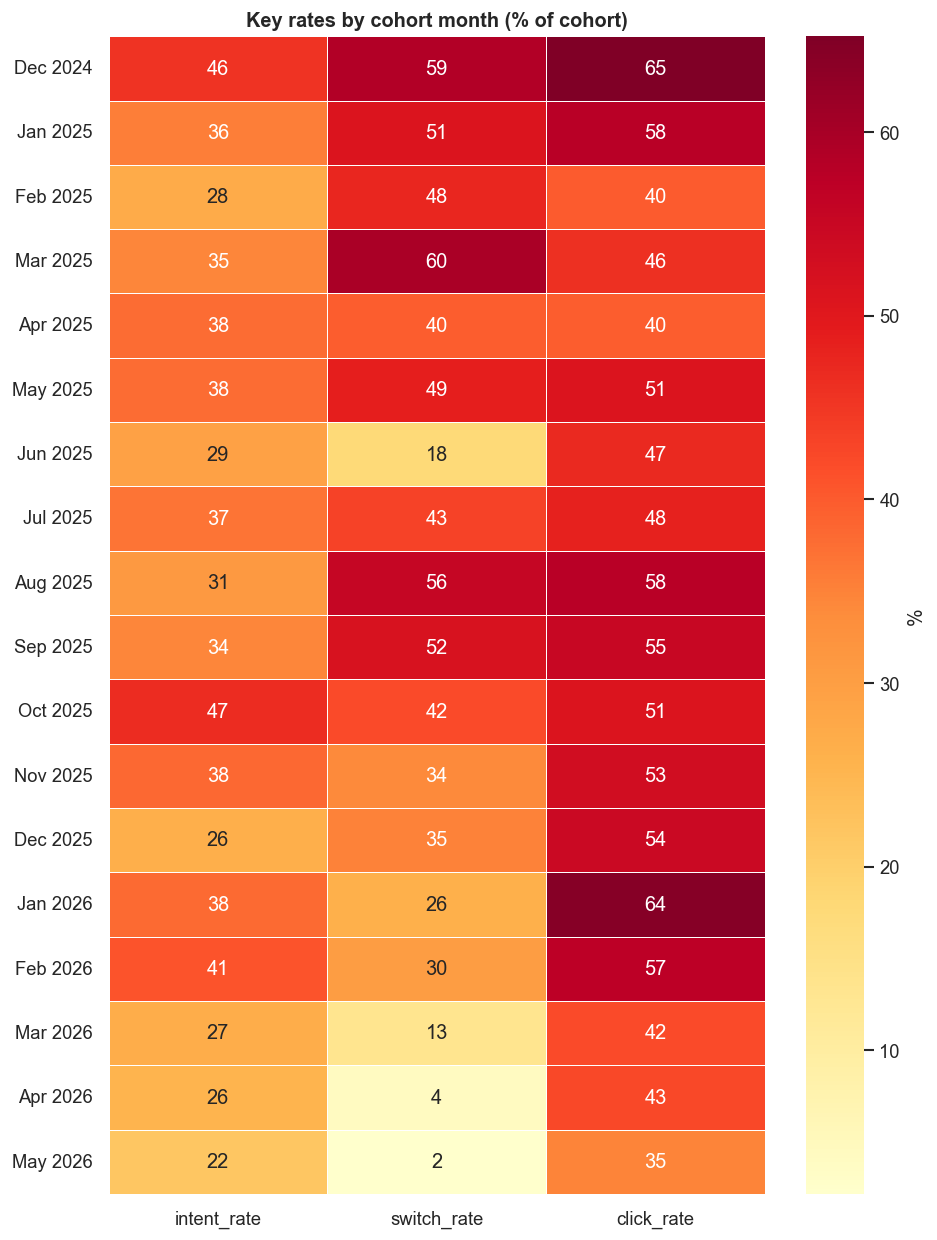

In [32]:
# Chart 6: Cohort consistency heatmap â€” are signals stable across cohort months?

cohort['cohort_month'] = cohort['first_email_date'].dt.to_period('M')

cohort_metrics = (
    cohort
    .groupby('cohort_month')
    .agg(
        n            =('mortgage_id', 'count'),
        intent_rate  =('had_intent',  'mean'),
        switch_rate  =('is_switched', 'mean'),
        click_rate   =('reached_email_clicked', 'mean')
    )
    .query('n >= 10')  # exclude tiny cohorts
    .mul({'n': 1, 'intent_rate': 100, 'switch_rate': 100, 'click_rate': 100})
    .drop(columns='n')
)
cohort_metrics.index = cohort_metrics.index.to_timestamp().strftime('%b %Y')

fig, ax = plt.subplots(figsize=(8, len(cohort_metrics) * 0.5 + 1.5))
sns.heatmap(
    cohort_metrics,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': '%'}
)
ax.set_title('Key rates by cohort month (% of cohort)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Key takeaways -- signal strength:**

- **The deeper into the funnel, the higher the switch rate**: Customers who clicked, logged in, and read content switched at higher rates than those who only received an email. The biggest jump, though, happens at the intent stage -- once a customer declares intent, the switch rate rises sharply above anything seen at earlier stages.
- **Intent is the clearest predictor we have**: Mortgages with an intent signal switch at a dramatically higher rate than those without. The logistic regression confirms this holds even when accounting for earlier engagement -- the other signals don't add much once intent is in the picture.
- **Intent tends to emerge early**: Most customers who will ever show intent do so within a short window after their first email. The median and p90 lines in Chart 5 show where that window closes. Late-emerging intent is the exception.
- **The pattern holds across cohorts**: The heatmap shows the same intent-to-switch relationship across every cohort month. Recent cohorts show lower switch rates simply because they have not had enough time to resolve -- not because the signal is weaker.

---
## 7. Engagement Timing

Does *when* a customer engages matter? Month 1 engagement vs months 2 and 3.

In [33]:
# assign each event to month 1, 2, or 3 relative to the mortgage first email
# engagement events have no mortgage_id, so route via consumer bridge
email_cohort_map = cohort.set_index('mortgage_id')['first_email_date'].to_dict()

engagement_events = (
    events[events['event_alias'].isin(['email_clicked', 'logged_in', 'subtopic_read', 'start_review'])]
    .merge(
        applicants.rename(columns={
            'applicant_consumer_id': 'event_consumer_id',
            'applicant_mortgage_id': 'mortgage_id'
        }),
        on='event_consumer_id',
        how='inner'
    )
    [['mortgage_id', 'event_created_date', 'event_alias']]
)

engagement_events['first_email'] = engagement_events['mortgage_id'].map(email_cohort_map)
engagement_events = engagement_events.dropna(subset=['first_email'])

engagement_events['months_since_email'] = (
    (engagement_events['event_created_date'].dt.year * 12 + engagement_events['event_created_date'].dt.month) -
    (engagement_events['first_email'].dt.year * 12 + engagement_events['first_email'].dt.month)
) + 1

for m in [1, 2, 3]:
    engaged_m = (
        engagement_events[engagement_events['months_since_email'] == m]
        ['mortgage_id'].unique()
    )
    cohort[f'engaged_m{m}'] = cohort['mortgage_id'].isin(engaged_m).astype(int)

print(cohort[['engaged_m1', 'engaged_m2', 'engaged_m3']].sum())


engaged_m1    239
engaged_m2    222
engaged_m3    287
dtype: int64


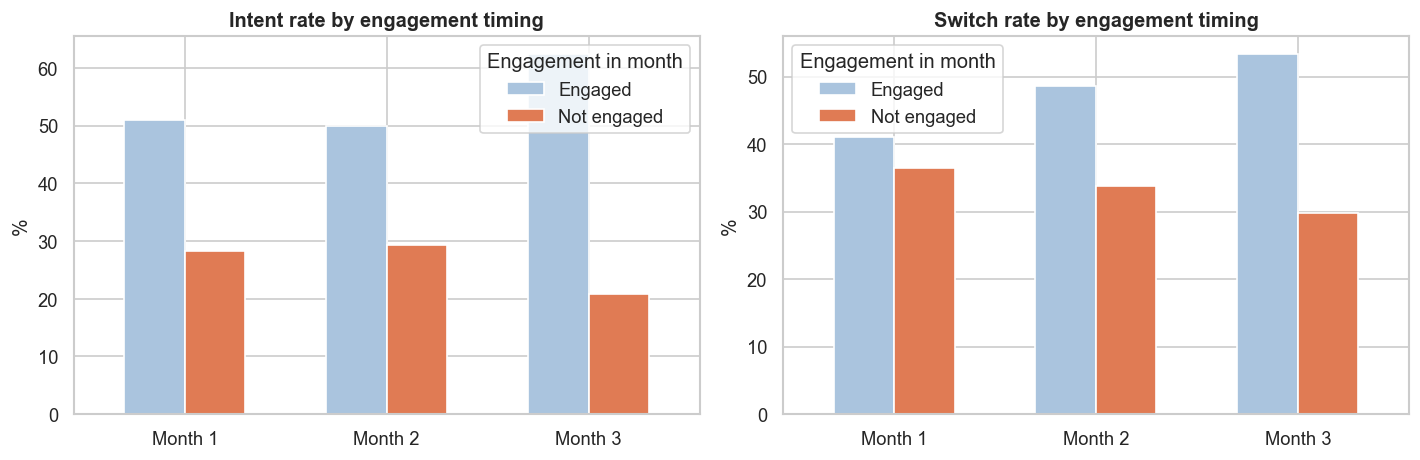

In [34]:
# Chart 7: Month 1/2/3 engagement vs intent rate

timing_results = []
for m in [1, 2, 3]:
    col = f'engaged_m{m}'
    for engaged in [0, 1]:
        sub = cohort[cohort[col] == engaged]
        timing_results.append({
            'month'      : f'Month {m}',
            'engaged'    : 'Engaged' if engaged else 'Not engaged',
            'intent_rate': sub['had_intent'].mean() * 100,
            'switch_rate': sub['is_switched'].mean() * 100,
            'n'          : len(sub)
        })

timing_df = pd.DataFrame(timing_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(
    axes,
    ['intent_rate', 'switch_rate'],
    ['Intent rate', 'Switch rate']
):
    pivot = timing_df.pivot(index='month', columns='engaged', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#aac4de', '#E07B54'], width=0.6)
    ax.set_title(f'{title} by engagement timing', fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.set_xticklabels(pivot.index, rotation=0)
    ax.legend(title='Engagement in month')

plt.tight_layout()
plt.show()

**Key takeaways -- engagement timing:**

- **Month 1 engagement is the strongest leading indicator**: Mortgages where a consumer engaged in the first month show materially higher intent and switch rates than those who only engaged in months 2 or 3. The first touchpoint appears to carry disproportionate weight.
- **Later engagement is partially reactive**: Month 2 and 3 engagers show an intent lift, but a narrower one. Engagement that arrives late in the window may reflect a customer already mid-decision rather than early-stage discovery.
- **Implication**: If month 1 engagement consistently predicts outcome better than months 2-3, the timing and content of the first contact matters more than follow-up frequency.

---
## 8. Limitations and Further Evidence

### What the data shows

The clearest signal is the `intent` event -- mortgages where intent was recorded switched at significantly higher rates, and the logistic regression confirms this holds after controlling for earlier funnel stages. The jump in switch rate is concentrated at the intent stage; earlier milestones (clicks, logins, content reads) show a positive association but do not independently predict switching once intent is in the model.

Timing also matters: mortgages where engagement happened in month 1 show higher intent and switch rates than those where engagement only appeared in months 2 or 3. This suggests the first interaction is disproportionately important, and that later engagement may partly reflect customers already mid-decision rather than early discovery.

The cohort heatmap shows the pattern is stable over time. Lower switch rates in recent cohorts are explained by the short observation window -- those mortgages have not yet had enough time to resolve.

### Limitations

**1. Selection into the cohort**  
Only mortgages that received an email enter the funnel. We don't know why some mortgages were never emailed -- if it correlates with lender configuration or product type, the funnel rates are confounded from the start.

**2. Causation vs correlation**  
The `intent` event likely reflects a decision the customer had already made, driven by external factors (rate environment, house move, life event). Engagement may be tracking that decision, not causing it. A customer who intends to switch will click the email; the click doesn't make them switch.

**3. Short observation window**  
Events start May 2024. Mortgages from late 2024 haven't had enough time to produce a `switched` or `redeemed` outcome yet, so their switch rates are understated. Recent cohorts look weaker than older ones partly because of this.

**4. Missing economic context**  
There is no data on the gap between each customer's current rate and available market rates, loan-to-value, or income. The incentive to switch is largely determined by that rate gap -- without it, we can't separate engagement effects from underlying switching propensity.

### What would strengthen the analysis

| Evidence | Why it matters |
|---|---|
| A/B test (randomise email outreach) | The only way to establish whether engagement causes switching rather than just correlating with it |
| Longer outcome window (2+ years) | Lets recent cohorts mature so their switch rates become observable |
| Rate delta per mortgage | Controls for the main economic driver of switching |
| Consumer demographics | Controls for selection -- who gets emailed and why |
| Exit survey or CRM notes | Separates engagement-driven switching from customers who were going to switch regardless |
| Rate history across lenders (SCD Type 2) | Customers switch only when the new rate offers a material benefit. Tracking what rates were offered to each customer over time -- across lenders -- would show whether switching is driven by a genuine rate improvement or platform engagement. If rates are similar, other benefits (fees, flexibility, adviser quality) become the deciding factor. |
| Macroeconomic variables | Switching decisions are tightly coupled with macro conditions: inflation at negotiation time, rate projections, household cost of living, debt capacity, and customer liquidity. Controlling for the macro environment would show whether engagement signals add predictive power above the baseline set by external pressures. |
| Qualitative feedback or CRM interactions | Intent events are binary -- they don't capture ambivalence, objections, or reasons for not switching. Customer-facing notes and survey data would distinguish browsers who are far from a decision from those who are close, and reveal perception of the switching process itself. |
| `start_review` conversion value | `start_review` sits between content consumption and stated intent. A conversion analysis -- how many customers who start a review go on to show intent, and whether they differ from customers who skip the review -- would clarify whether this step adds meaningful signal or is largely a pass-through. |
| Other contact channels | The dataset contains only email events. Other channels (push notifications, SMS, adviser calls) may exist but are either untested or not shared. A channel comparison would show whether email is the most effective touchpoint or whether most switching is driven by off-platform interactions outside the current data scope. |